In [26]:
! pip install kaggle


[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [28]:
import os

os.getcwd()


'c:\\xampp\\htdocs\\machine_learning\\praktikum\\praktikum11\\notebook'

In [29]:
import os

BASE_DATASET = r"C:\xampp\htdocs\machine_learning\tugas\tugas13\dataset"

data_0 = os.listdir(os.path.join(BASE_DATASET, "0"))
data_1 = os.listdir(os.path.join(BASE_DATASET, "1"))
data_2 = os.listdir(os.path.join(BASE_DATASET, "2"))
data_3 = os.listdir(os.path.join(BASE_DATASET, "3"))
data_4 = os.listdir(os.path.join(BASE_DATASET, "4"))
data_5 = os.listdir(os.path.join(BASE_DATASET, "5"))
data_6 = os.listdir(os.path.join(BASE_DATASET, "6"))
data_7 = os.listdir(os.path.join(BASE_DATASET, "7"))
data_8 = os.listdir(os.path.join(BASE_DATASET, "8"))
data_9 = os.listdir(os.path.join(BASE_DATASET, "9"))


In [30]:
print(len(data_0))


2236


In [31]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


In [32]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)


Train shape: (60000, 28, 28)
Test shape : (10000, 28, 28)


In [33]:
X_train = X_train.reshape(X_train.shape[0], 28*28)
X_test  = X_test.reshape(X_test.shape[0], 28*28)


In [34]:
X_train = X_train / 255.0
X_test  = X_test / 255.0


In [35]:
y_train_cat = to_categorical(y_train, 10)
y_test_cat  = to_categorical(y_test, 10)


In [36]:
model = Sequential()

# Input layer + Hidden layer 1
model.add(Dense(128, activation='relu', input_shape=(784,)))

# Hidden layer 2
model.add(Dense(64, activation='relu'))

# Output layer
model.add(Dense(10, activation='softmax'))

model.summary()


c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [38]:
history = model.fit(
    X_train, y_train_cat,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)



Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9195 - loss: 0.2739 - val_accuracy: 0.9592 - val_loss: 0.1410
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9654 - loss: 0.1162 - val_accuracy: 0.9668 - val_loss: 0.1174
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9754 - loss: 0.0783 - val_accuracy: 0.9670 - val_loss: 0.1124
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9814 - loss: 0.0586 - val_accuracy: 0.9714 - val_loss: 0.1040
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9857 - loss: 0.0445 - val_accuracy: 0.9743 - val_loss: 0.0931
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9876 - loss: 0.0375 - val_accuracy: 0.9744 - val_loss: 0.0938
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9902 - loss: 0.0293 - val_accuracy: 0.9737 - val_loss: 0.1012
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9914 - loss: 0.0261 - 

In [39]:
test_loss, test_accuracy = model.evaluate(X_test, y_test_cat)
print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9797 - loss: 0.1244
Test Accuracy: 0.9797000288963318
Test Loss: 0.12437859177589417


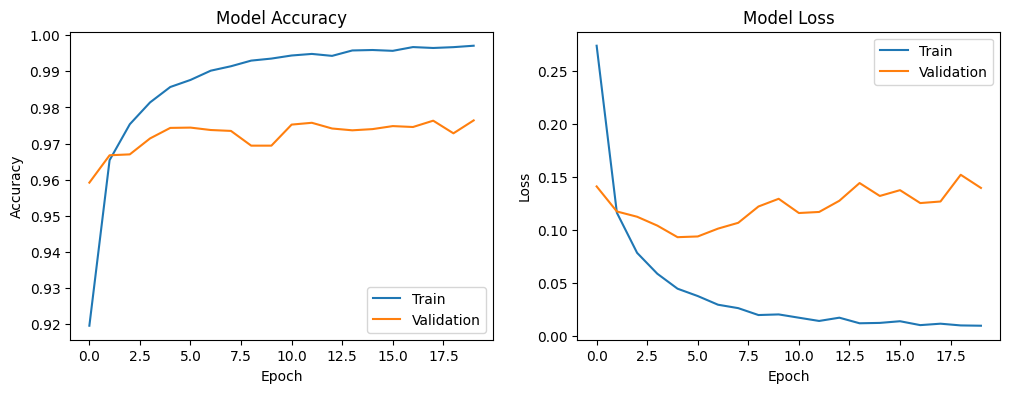

In [40]:
plt.figure(figsize=(12,4))

# Akurasi
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


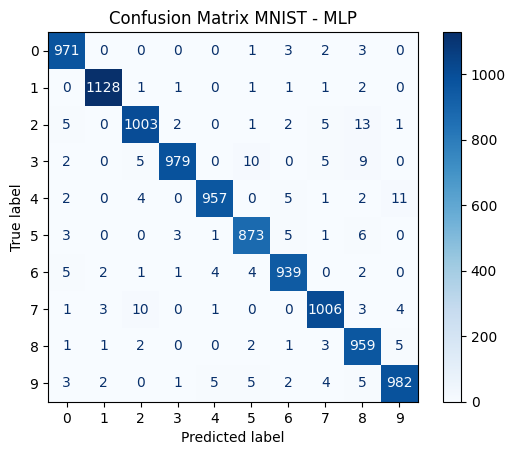

In [41]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix MNIST - MLP")
plt.show()


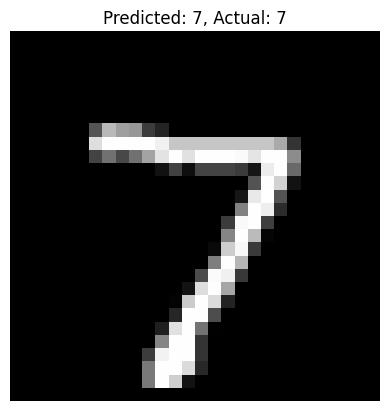

In [42]:
index = 0
plt.imshow(X_test[index].reshape(28,28), cmap='gray')
plt.title(f"Predicted: {y_pred_classes[index]}, Actual: {y_test[index]}")
plt.axis('off')
plt.show()


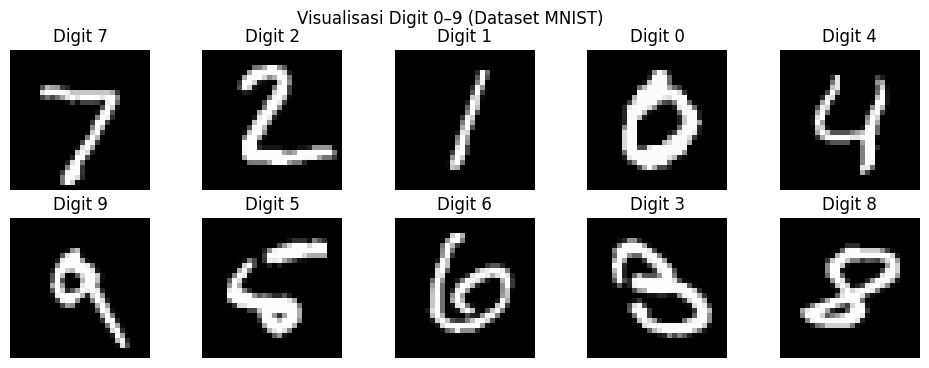

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

shown = set()
i = 0

while len(shown) < 10:
    label = y_test[i]
    if label not in shown:
        plt.subplot(2,5,len(shown)+1)
        plt.imshow(X_test[i].reshape(28,28), cmap='gray')
        plt.title(f"Digit {label}")
        plt.axis('off')
        shown.add(label)
    i += 1

plt.suptitle("Visualisasi Digit 0–9 (Dataset MNIST)")
plt.show()
